# Logistic Regression for Customer Churn Prediction

In [61]:
# Step 1: Import the important Libraries

In [62]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [63]:
# Step 2: Load the Dataset

churn_data = pd.read_csv("churn_data.csv")
churn_data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [64]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   object 
 3   Contract          7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   Churn             7043 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 495.3+ KB


In [65]:
churn_data.shape

(7043, 9)

In [66]:
churn_data.dtypes

customerID           object
tenure                int64
PhoneService         object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [67]:
churn_data["PhoneService"].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [68]:
churn_data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [69]:
churn_data["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [70]:
churn_data["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [71]:
churn_data["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

## Data Cleaning and Prepration

In [72]:
churn_data.shape

(7043, 9)

In [73]:
churn_data.isnull().sum()

customerID          0
tenure              0
PhoneService        0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [74]:
churn_data.select_dtypes(include=['object']).columns

Index(['customerID', 'PhoneService', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [75]:
churn_data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [76]:
label_encoders ={}

for column in churn_data.select_dtypes(include=['object']).columns:
    if column!= 'customerID':
        label_encoders[column]=LabelEncoder()
        churn_data[column]=label_encoders[column].fit_transform(churn_data[column])
        

In [77]:
churn_data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,0,1,2,29.85,2505,0
1,5575-GNVDE,34,1,1,0,3,56.95,1466,0
2,3668-QPYBK,2,1,0,1,3,53.85,157,1
3,7795-CFOCW,45,0,1,0,0,42.30,1400,0
4,9237-HQITU,2,1,0,1,2,70.70,925,1


In [78]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   int64  
 3   Contract          7043 non-null   int64  
 4   PaperlessBilling  7043 non-null   int64  
 5   PaymentMethod     7043 non-null   int64  
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   int64  
 8   Churn             7043 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 495.3+ KB


## Define Independent and Dependent Variable

In [79]:
X = churn_data.drop(columns=["customerID","Churn"])
y = churn_data['Churn']
X.head()

,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,0,1,2,29.85,2505
1,34,1,1,0,3,56.95,1466
2,2,1,0,1,3,53.85,157
3,45,0,1,0,0,42.30,1400
4,2,1,0,1,2,70.70,925


In [80]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [81]:
X.shape, y.shape

((7043, 7), (7043,))

## Split the data for train and test

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [83]:
X_train.shape, y_train.shape

((5634, 7), (5634,))

In [84]:
X_test.shape, y_test.shape

((1409, 7), (1409,))

In [85]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [86]:
X_train

array([[-4.65683364e-01,  3.29573443e-01,  3.72908354e-01, ...,
         1.33926673e+00, -4.73723375e-04, -1.40800618e+00],
       [ 8.85536787e-01,  3.29573443e-01,  1.57759050e+00, ...,
        -1.47094882e+00,  1.07475386e+00,  5.58360318e-01],
       [-1.28460467e+00, -3.03422506e+00, -8.31773795e-01, ...,
         4.02528212e-01, -1.37649913e+00, -7.02892284e-01],
       ...,
       [-8.34197950e-01,  3.29573443e-01, -8.31773795e-01, ...,
         4.02528212e-01, -1.45294499e+00, -3.21706651e-01],
       [-8.34197950e-01,  3.29573443e-01, -8.31773795e-01, ...,
         4.02528212e-01,  1.14953785e+00, -1.53524478e+00],
       [-2.60953038e-01,  3.29573443e-01,  3.72908354e-01, ...,
        -5.34210304e-01, -1.49781538e+00,  3.30921324e-01]],
      shape=(5634, 7))

In [87]:
X_test

array([[-1.28460467, -3.03422506, -0.83177379, ...,  0.40252821,
        -1.33162874, -0.64775556],
       [ 0.35323794,  0.32957344, -0.83177379, ..., -1.47094882,
        -1.31667194,  1.72630461],
       [ 0.80364466,  0.32957344,  1.5775905 , ...,  1.33926673,
        -1.51277218, -1.69588351],
       ...,
       [-0.62946762,  0.32957344,  0.37290835, ..., -1.47094882,
        -1.49449165, -0.21726497],
       [ 1.49972776, -3.03422506,  1.5775905 , ..., -0.5342103 ,
        -0.69513389, -0.37631322],
       [-1.28460467, -3.03422506, -0.83177379, ...,  1.33926673,
        -1.11392424, -0.30156054]], shape=(1409, 7))

In [88]:
y_train.head()

2142    0
1623    0
6074    1
1362    1
6754    0
Name: Churn, dtype: int64

## Building our  first logistic Regression Model

In [89]:
from sklearn.linear_model import LogisticRegression

In [90]:
model = LogisticRegression()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)


In [91]:
y_pred

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [92]:
y_test

185     1
2715    0
3825    0
1807    1
132     0
       ..
6366    0
315     0
2439    0
5002    0
1161    1
Name: Churn, Length: 1409, dtype: int64

## Recursive Feature Elimination

In [93]:
from sklearn.feature_selection import RFE

rfe_model = LogisticRegression()

rfe = RFE(estimator = rfe_model, n_features_to_select = 5)

In [94]:
#Fit RFE
rfe.fit(X_train, y_train)

# Get the selected features
selectd_feates = rfe.support_

#Transform the dataset
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

# Retrain the model on the selected features
model.fit(X_train_rfe, y_train)

# Make predictions

y_pred_rfe = model.predict(X_test_rfe)


## Model Evaluation Metrics - Consusion Matrix and Accuracy

In [95]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Generate the confusion matrix

conf_matrix = confusion_matrix(y_test,y_pred_rfe)
print("Confusion matrix:\n", conf_matrix)

#Calculate accuracy

accuracy = accuracy_score(y_test, y_pred_rfe)
print("Accuracy:",accuracy)

Confusion matrix:
 [[937  99]
 [170 203]]
Accuracy: 0.8090844570617459


## Metrics Beyond Accuracy: Sensitivity & Specificity

In [97]:
# Calaculate Sensitivity(recall) and specificity

from sklearn.metrics import recall_score

# Sensitivity(recall)

sensitivity = recall_score(y_test,y_pred_rfe)
print("sensitivity:", sensitivity)
# specificity
tn, fp, fn, tp = confusion_matrix(y_test,y_pred_rfe).ravel()
specificity = tn/(tn+fp)
print("specificity:", specificity)


sensitivity: 0.5442359249329759
specificity: 0.9044401544401545


## ROC Curve

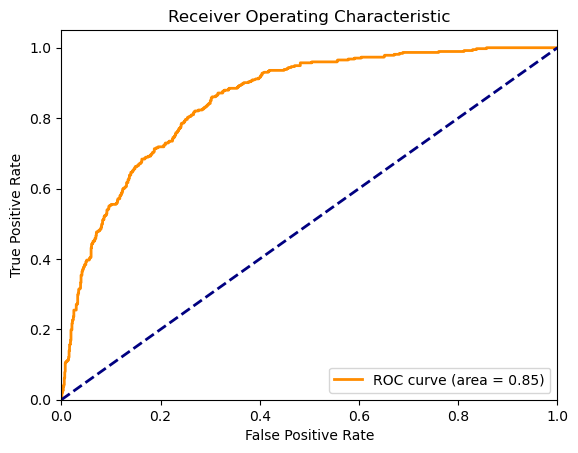

In [98]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test_rfe)[:, 1])

# Plot ROC curve
plt.figure()

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, model.predict_proba(X_test_rfe)[:, 1]))




# Plotting the ROC (Receiver Operating Characteristic) Curve:
# - `fpr` (x-axis): False Positive Rate (1 - Specificity)
# - `tpr` (y-axis): True Positive Rate (Sensitivity/Recall)
# - `color='darkorange'`: Curve color (standard for visibility)
# - `lw=2`: Line width for better visibility
# - `label`: Shows AUC (Area Under Curve) score (0.5 = random, 1.0 = perfect)
# - `roc_auc_score()` calculates the AUC to quantify model performance (higher = better)




plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


## Calaculate precision and recall

In [99]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred_rfe)
recall = recall_score(y_test, y_pred_rfe)

print("Precision:",precision )
print("Recall:",recall )

Precision: 0.6721854304635762
Recall: 0.5442359249329759
